In [3]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import torch
import matplotlib.pyplot as plt

from data import all_atom, so3_utils
from openfold.data import data_transforms
from openfold.utils import rigid_utils

sns.set_theme(style="whitegrid", context="talk")


In [4]:
target_traj_path = Path("/home/zichong_wang/ReQFlow/inference_outputs/ckpts/reqflow_pdb_rectify/reqflow_pdb_rectify/unconditional/path_analyze/run_2026-01-08_21-39-47/length_100/sample_0/traj.pt")
target_traj = torch.load(target_traj_path, map_location="cpu").float()
target_traj.shape


torch.Size([501, 1500])

In [5]:
base_dir = target_traj_path.parents[3]
run_dirs = sorted([p for p in base_dir.glob("run_*") if p.is_dir()])

entries = []
label_by_run = {}
for run_dir in run_dirs:
    txt_files = sorted(run_dir.glob("*.txt"))
    label = txt_files[0].stem if txt_files else run_dir.name
    traj_path = run_dir / "length_100" / "sample_0" / "traj.pt"
    if not traj_path.exists():
        raise FileNotFoundError(f"Missing traj.pt: {traj_path}")
    traj = torch.load(traj_path, map_location="cpu").float()
    if traj.ndim != 2:
        raise ValueError(f"Expected 2D traj, got shape {traj.shape} from {traj_path}")
    entries.append((label, traj))
    label_by_run[run_dir.name] = label

entries = sorted(entries, key=lambda x: x[0])
labels = [label for label, _ in entries]
lengths = [traj.shape[0] for _, traj in entries]
if len(set(lengths)) != 1:
    raise ValueError(f"Mismatched step counts: {lengths}")

target_run = target_traj_path.parents[2].name
target_label = label_by_run.get(target_run)
if target_label is None:
    raise ValueError(f"Target run {target_run} not found under {base_dir}")
traj_by_label = {label: traj for label, traj in entries}
target_traj = traj_by_label[target_label]


In [6]:
def traj_step_to_atom37(step_vec, num_res):
    step = step_vec.reshape(num_res, 5, 3)
    atom37 = torch.zeros(num_res, 37, 3, dtype=step.dtype)
    atom37[:, :5, :] = step
    mask = torch.zeros(num_res, 37, dtype=step.dtype)
    mask[:, :5] = 1.0
    return atom37, mask


def atom37_to_trans_rotquats(atom37, mask):
    feats = {
        "aatype": torch.zeros(atom37.shape[0], dtype=torch.long),
        "all_atom_positions": atom37.double(),
        "all_atom_mask": mask.double(),
    }
    feats = data_transforms.atom37_to_frames(feats)
    rigids = rigid_utils.Rigid.from_tensor_4x4(feats["rigidgroups_gt_frames"])[:, 0]
    trans = rigids.get_trans().float()
    rotquats = rigids.get_rots().get_quats().float()
    return trans, rotquats


def traj_step_to_dq(step_vec, num_res):
    atom37, mask = traj_step_to_atom37(step_vec, num_res)
    trans, rotquats = atom37_to_trans_rotquats(atom37, mask)
    trans = trans.unsqueeze(0)
    rotquats = rotquats.unsqueeze(0)
    dq = so3_utils.trans_rot_to_dq(trans, rotquats)
    return dq


def dq_to_bb5(dq):
    trans, rotquats = so3_utils.dq_to_trans_rot(dq)
    rotmats = rigid_utils.quat_to_rot(rotquats)
    atom37 = all_atom.atom37_from_trans_rot(trans, rotmats)
    return atom37[:, :, :5, :]


num_res = target_traj.shape[1] // 15
start_vec = target_traj[0]
end_vec = target_traj[-1]
mid_idx = target_traj.shape[0] // 2
model_mid_vec = target_traj[mid_idx]

dq_start = traj_step_to_dq(start_vec, num_res)
dq_end = traj_step_to_dq(end_vec, num_res)

interp_t = torch.full((1, num_res), 0.5)
interp_method = "KenLERP"  # "ScLERP" or "KenLERP"
kenlerp_beta = 0.5

method = interp_method.lower()
if method == "sclerp":
    dq_mid = so3_utils.sclerp_batch(dq_start, dq_end, interp_t)
elif method == "kenlerp":
    dq_mid = so3_utils.kenlerp_batch(dq_start, dq_end, interp_t, beta=kenlerp_beta)
else:
    raise ValueError(f"Unknown interp_method: {interp_method}")

bb5_mid = dq_to_bb5(dq_mid)
dq_mid_vec = bb5_mid.reshape(-1)

model_mid_bb5 = model_mid_vec.reshape(num_res, 5, 3)
dq_mid_bb5 = bb5_mid.squeeze(0)

rmsd = torch.sqrt(torch.mean((dq_mid_bb5 - model_mid_bb5) ** 2)).item()
mean_atom_dist = torch.linalg.norm(dq_mid_bb5 - model_mid_bb5, dim=-1).mean().item()
max_atom_dist = torch.linalg.norm(dq_mid_bb5 - model_mid_bb5, dim=-1).max().item()

rmsd, mean_atom_dist, max_atom_dist


(1.5360041856765747, 2.275918483734131, 9.091193199157715)

dq_mid RMSD: 1.5360041856765747
median step RMSD: 0.024167193099856377
ratio to median step: 63.55740939090287
dq_mid percentile vs mid-to-all-steps: 25.34930109977722


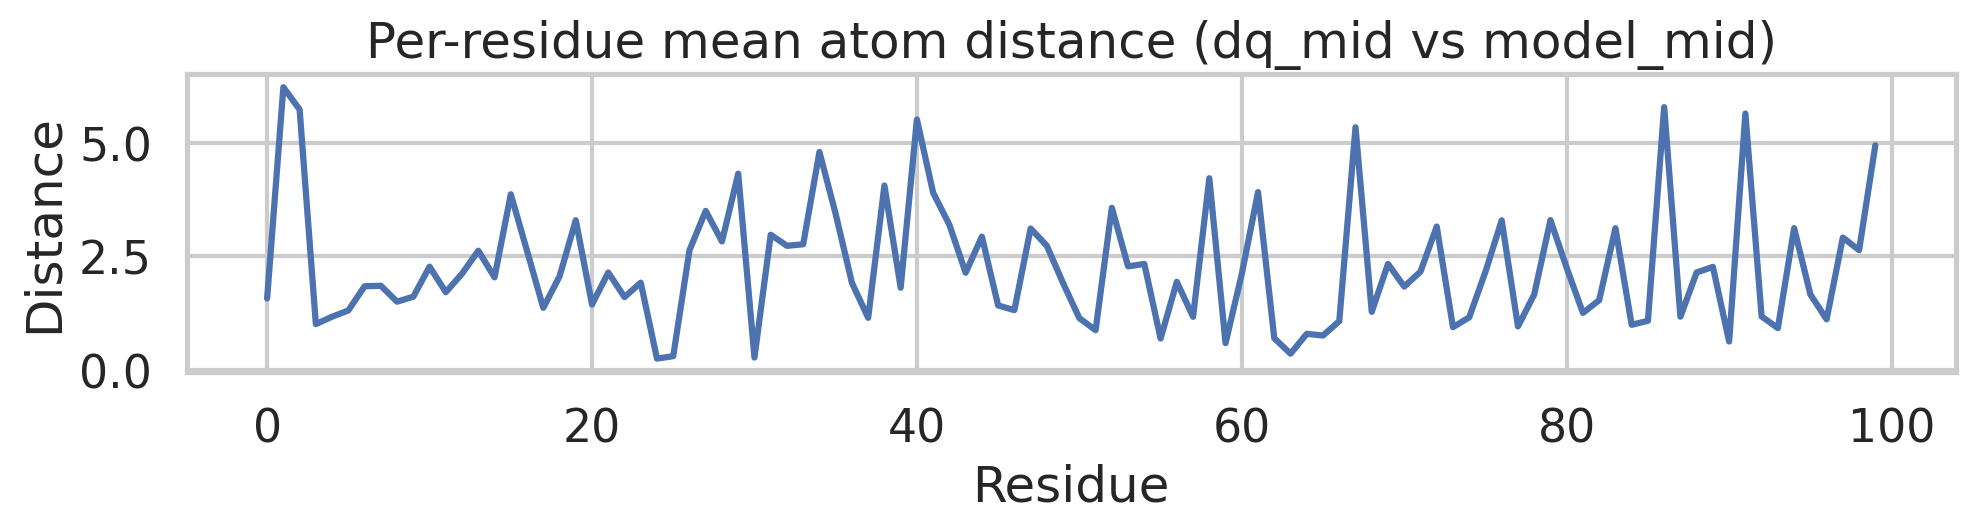

In [14]:
# Baselines to interpret dq_mid vs model_mid
traj_bb5 = target_traj.reshape(-1, num_res, 5, 3)

def rmsd(a, b):
    return torch.sqrt(torch.mean((a - b) ** 2)).item()

dq_mid_rmsd = rmsd(dq_mid_bb5, model_mid_bb5)

# 1) Typical step-to-step size
step_rmsd = torch.sqrt(torch.mean((traj_bb5[1:] - traj_bb5[:-1]) ** 2, dim=(1, 2, 3)))
print("dq_mid RMSD:", dq_mid_rmsd)
print("median step RMSD:", step_rmsd.median().item())
print("ratio to median step:", dq_mid_rmsd / step_rmsd.median().item())

# 2) Where dq_mid sits in the mid-to-all-steps distribution
mid_to_all = torch.sqrt(torch.mean((traj_bb5 - model_mid_bb5) ** 2, dim=(1, 2, 3)))
percentile = (mid_to_all <= dq_mid_rmsd).float().mean().item() * 100
print("dq_mid percentile vs mid-to-all-steps:", percentile)

# 3) Per-residue localization (mean over 5 atoms)
per_res = torch.linalg.norm(dq_mid_bb5 - model_mid_bb5, dim=-1).mean(dim=-1)
plt.figure(figsize=(10, 3), dpi=200)
plt.plot(per_res.numpy())
plt.title("Per-residue mean atom distance (dq_mid vs model_mid)")
plt.xlabel("Residue")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


In [16]:
model_mid_bb5.mean()

tensor(-0.0232)

In [7]:
X = torch.cat([traj for _, traj in entries], dim=0).cpu().numpy()
if X.shape[0] != 2004:
    print(f"Warning: expected 2004 rows, got {X.shape[0]}")

X_mean = X.mean(axis=0, keepdims=True)
X_centered = X - X_mean
_, _, vt = np.linalg.svd(X_centered, full_matrices=False)
X_2d = X_centered @ vt[:2].T

rows = []
offset = 0
for label, traj in entries:
    n_steps = traj.shape[0]
    coords = X_2d[offset:offset + n_steps]
    df = pd.DataFrame(coords, columns=["PC1", "PC2"])
    df["step"] = np.arange(n_steps)
    df["label"] = label
    rows.append(df)
    offset += n_steps

traj_df = pd.concat(rows, ignore_index=True)

dq_mid_2d = (dq_mid_vec.cpu().numpy()[None, :] - X_mean) @ vt[:2].T
model_mid_2d = (model_mid_vec.cpu().numpy()[None, :] - X_mean) @ vt[:2].T
mid_df = pd.DataFrame(
    {
        "PC1": [dq_mid_2d[0, 0], model_mid_2d[0, 0]],
        "PC2": [dq_mid_2d[0, 1], model_mid_2d[0, 1]],
        "kind": ["dq_mid", "model_mid"],
    }
)
mid_df["label"] = [f"{target_label} dq_mid", f"{target_label} model_mid"]


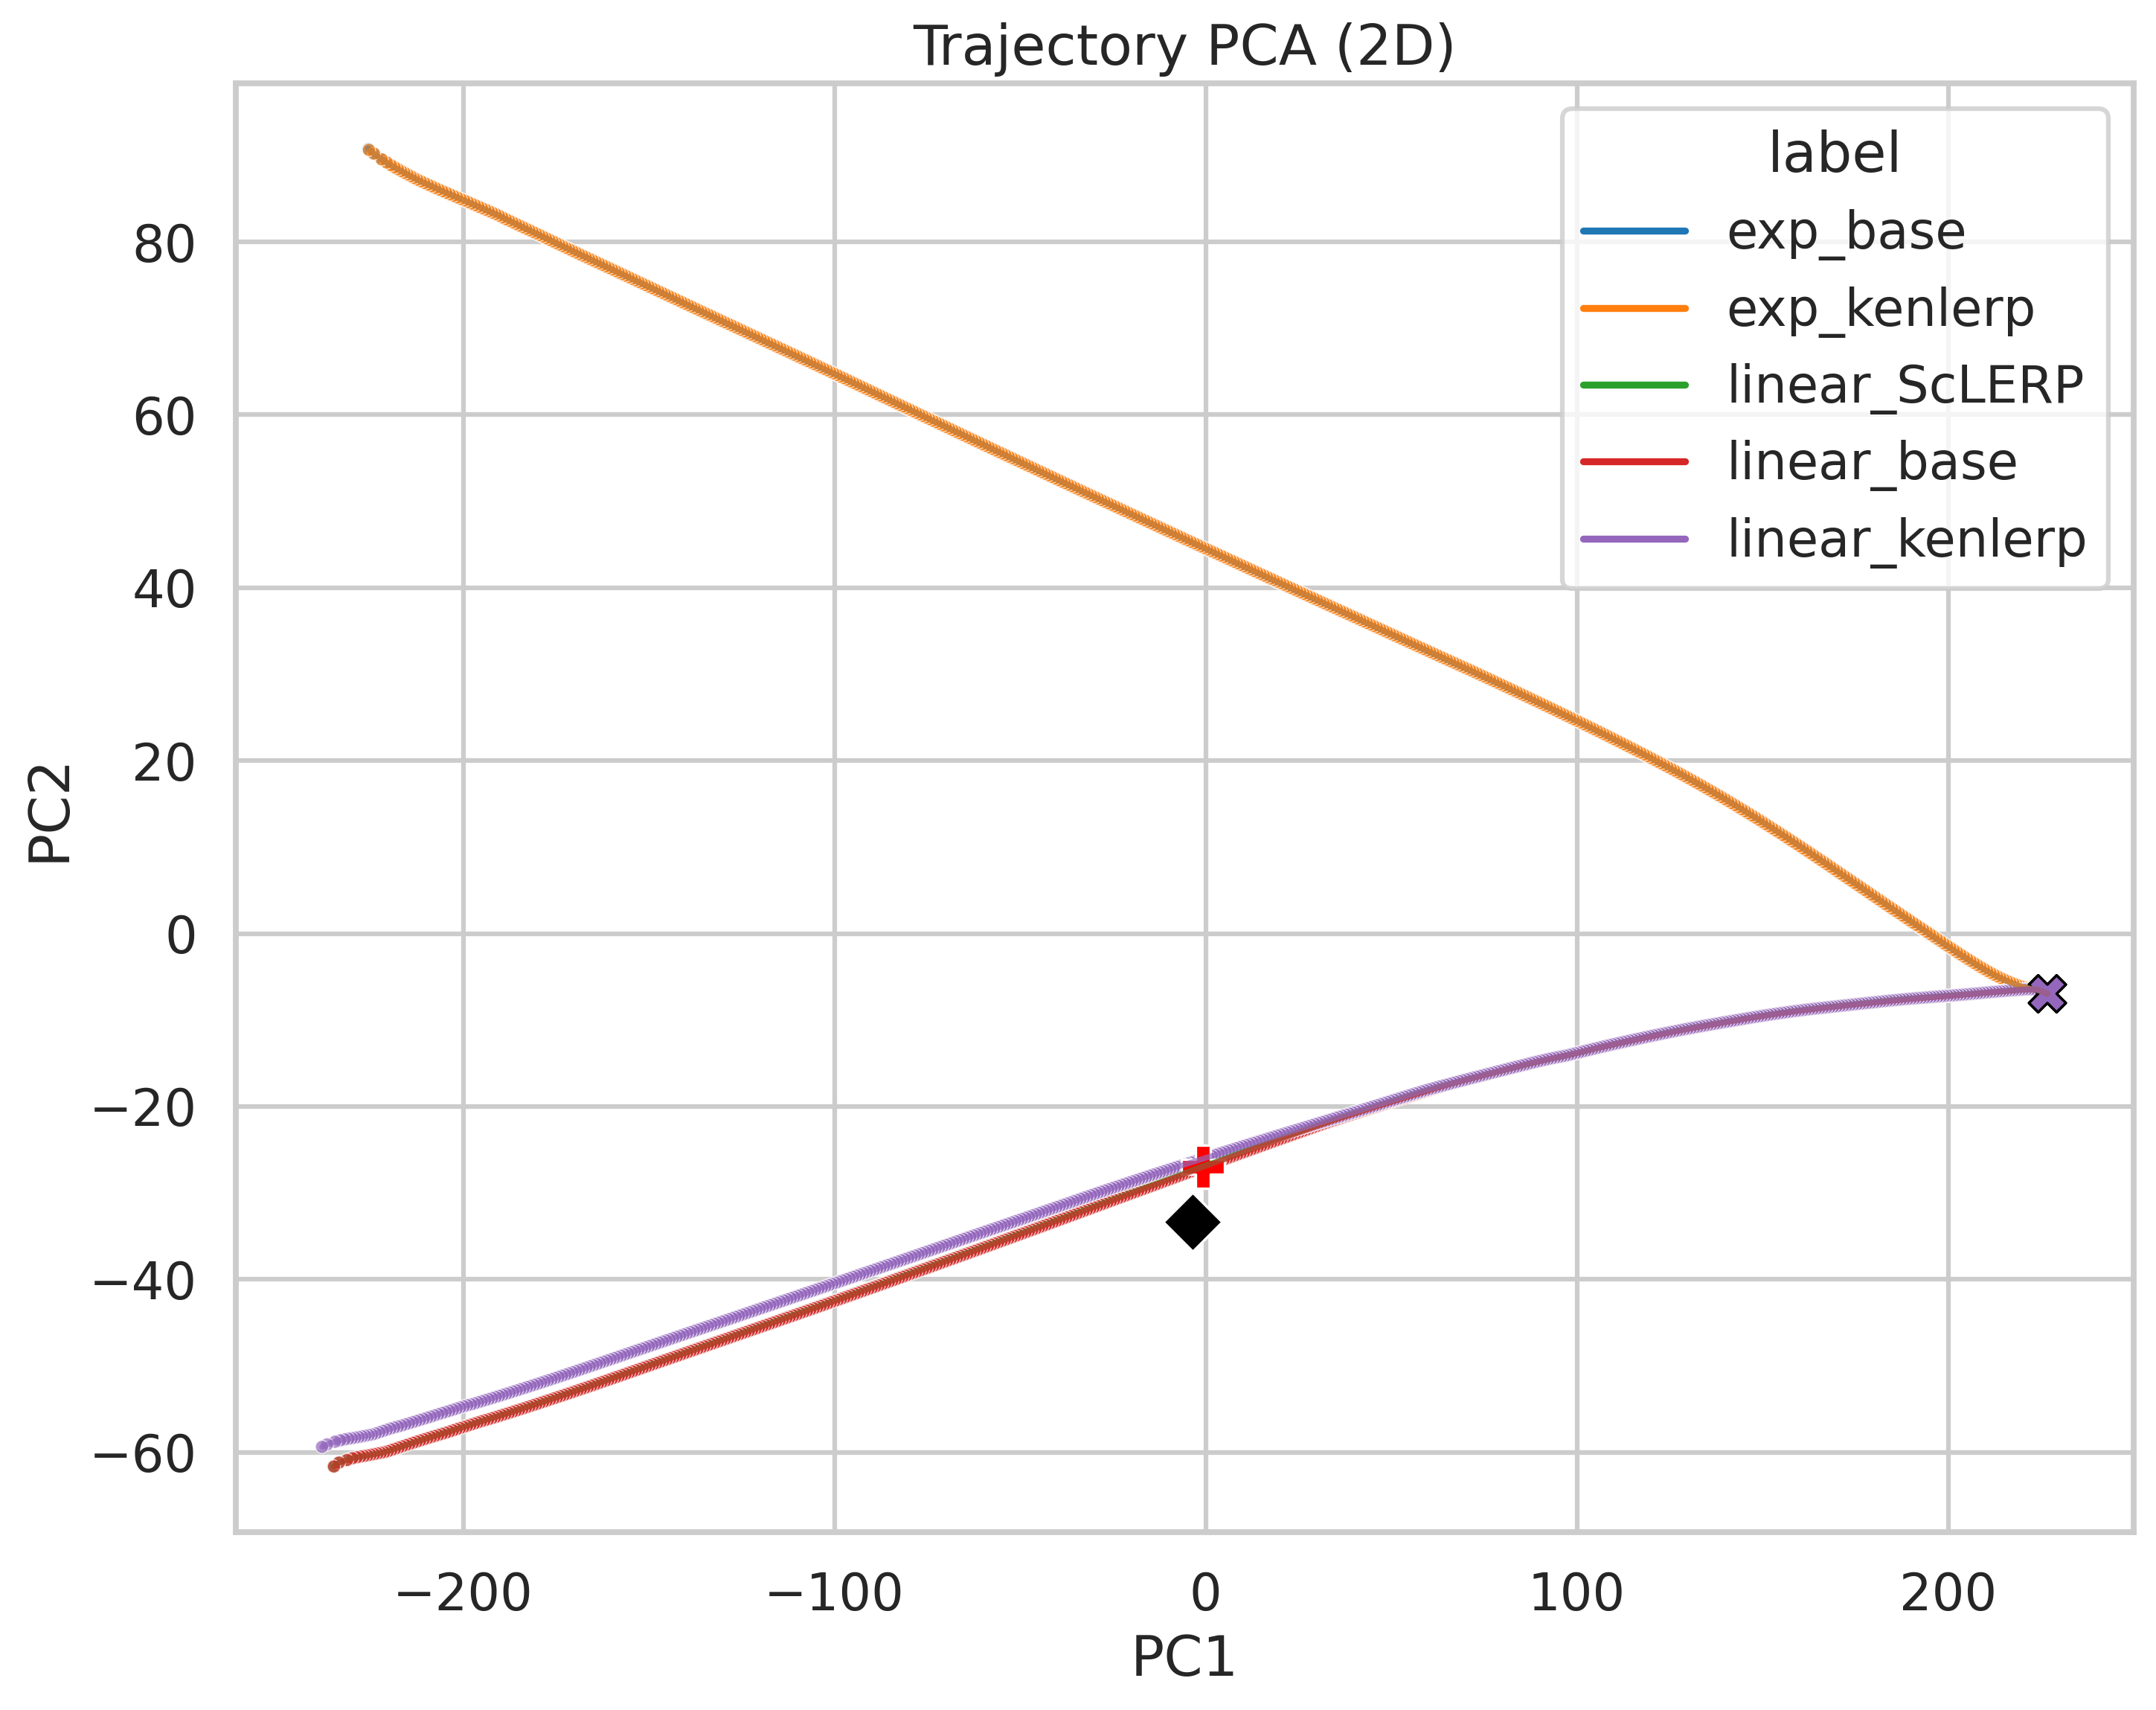

In [13]:
palette = dict(zip(labels, sns.color_palette("tab10", len(labels))))
start_df = traj_df[traj_df["step"] == 0].copy()

plt.figure(figsize=(10, 8), dpi=300)
sns.lineplot(
    data=traj_df,
    x="PC1",
    y="PC2",
    hue="label",
    estimator=None,
    linewidth=1.8,
    alpha=0.7,
    palette=palette,
)
sns.scatterplot(
    data=traj_df,
    x="PC1",
    y="PC2",
    hue="label",
    s=18,
    alpha=0.7,
    palette=palette,
    legend=False,
)
sns.scatterplot(
    data=start_df,
    x="PC1",
    y="PC2",
    hue="label",
    s=140,
    marker="X",
    edgecolor="black",
    linewidth=0.8,
    palette=palette,
    legend=False,
)

dq_point = mid_df[mid_df["kind"] == "dq_mid"]
model_point = mid_df[mid_df["kind"] == "model_mid"]
plt.scatter(
    dq_point["PC1"],
    dq_point["PC2"],
    s=180,
    marker="D",
    color="black",
    edgecolor="white",
    linewidth=0.8,
)
plt.scatter(
    model_point["PC1"],
    model_point["PC2"],
    s=200,
    marker="P",
    color="red",
    edgecolor="white",
    linewidth=0.8,
)
# plt.annotate(
#     dq_point["label"].iloc[0],
#     (dq_point["PC1"].iloc[0], dq_point["PC2"].iloc[0]),
#     textcoords="offset points",
#     xytext=(6, 12),
# )
# plt.annotate(
#     model_point["label"].iloc[0],
#     (model_point["PC1"].iloc[0], model_point["PC2"].iloc[0]),
#     textcoords="offset points",
#     xytext=(6, -12),
# )

plt.title("Trajectory PCA (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


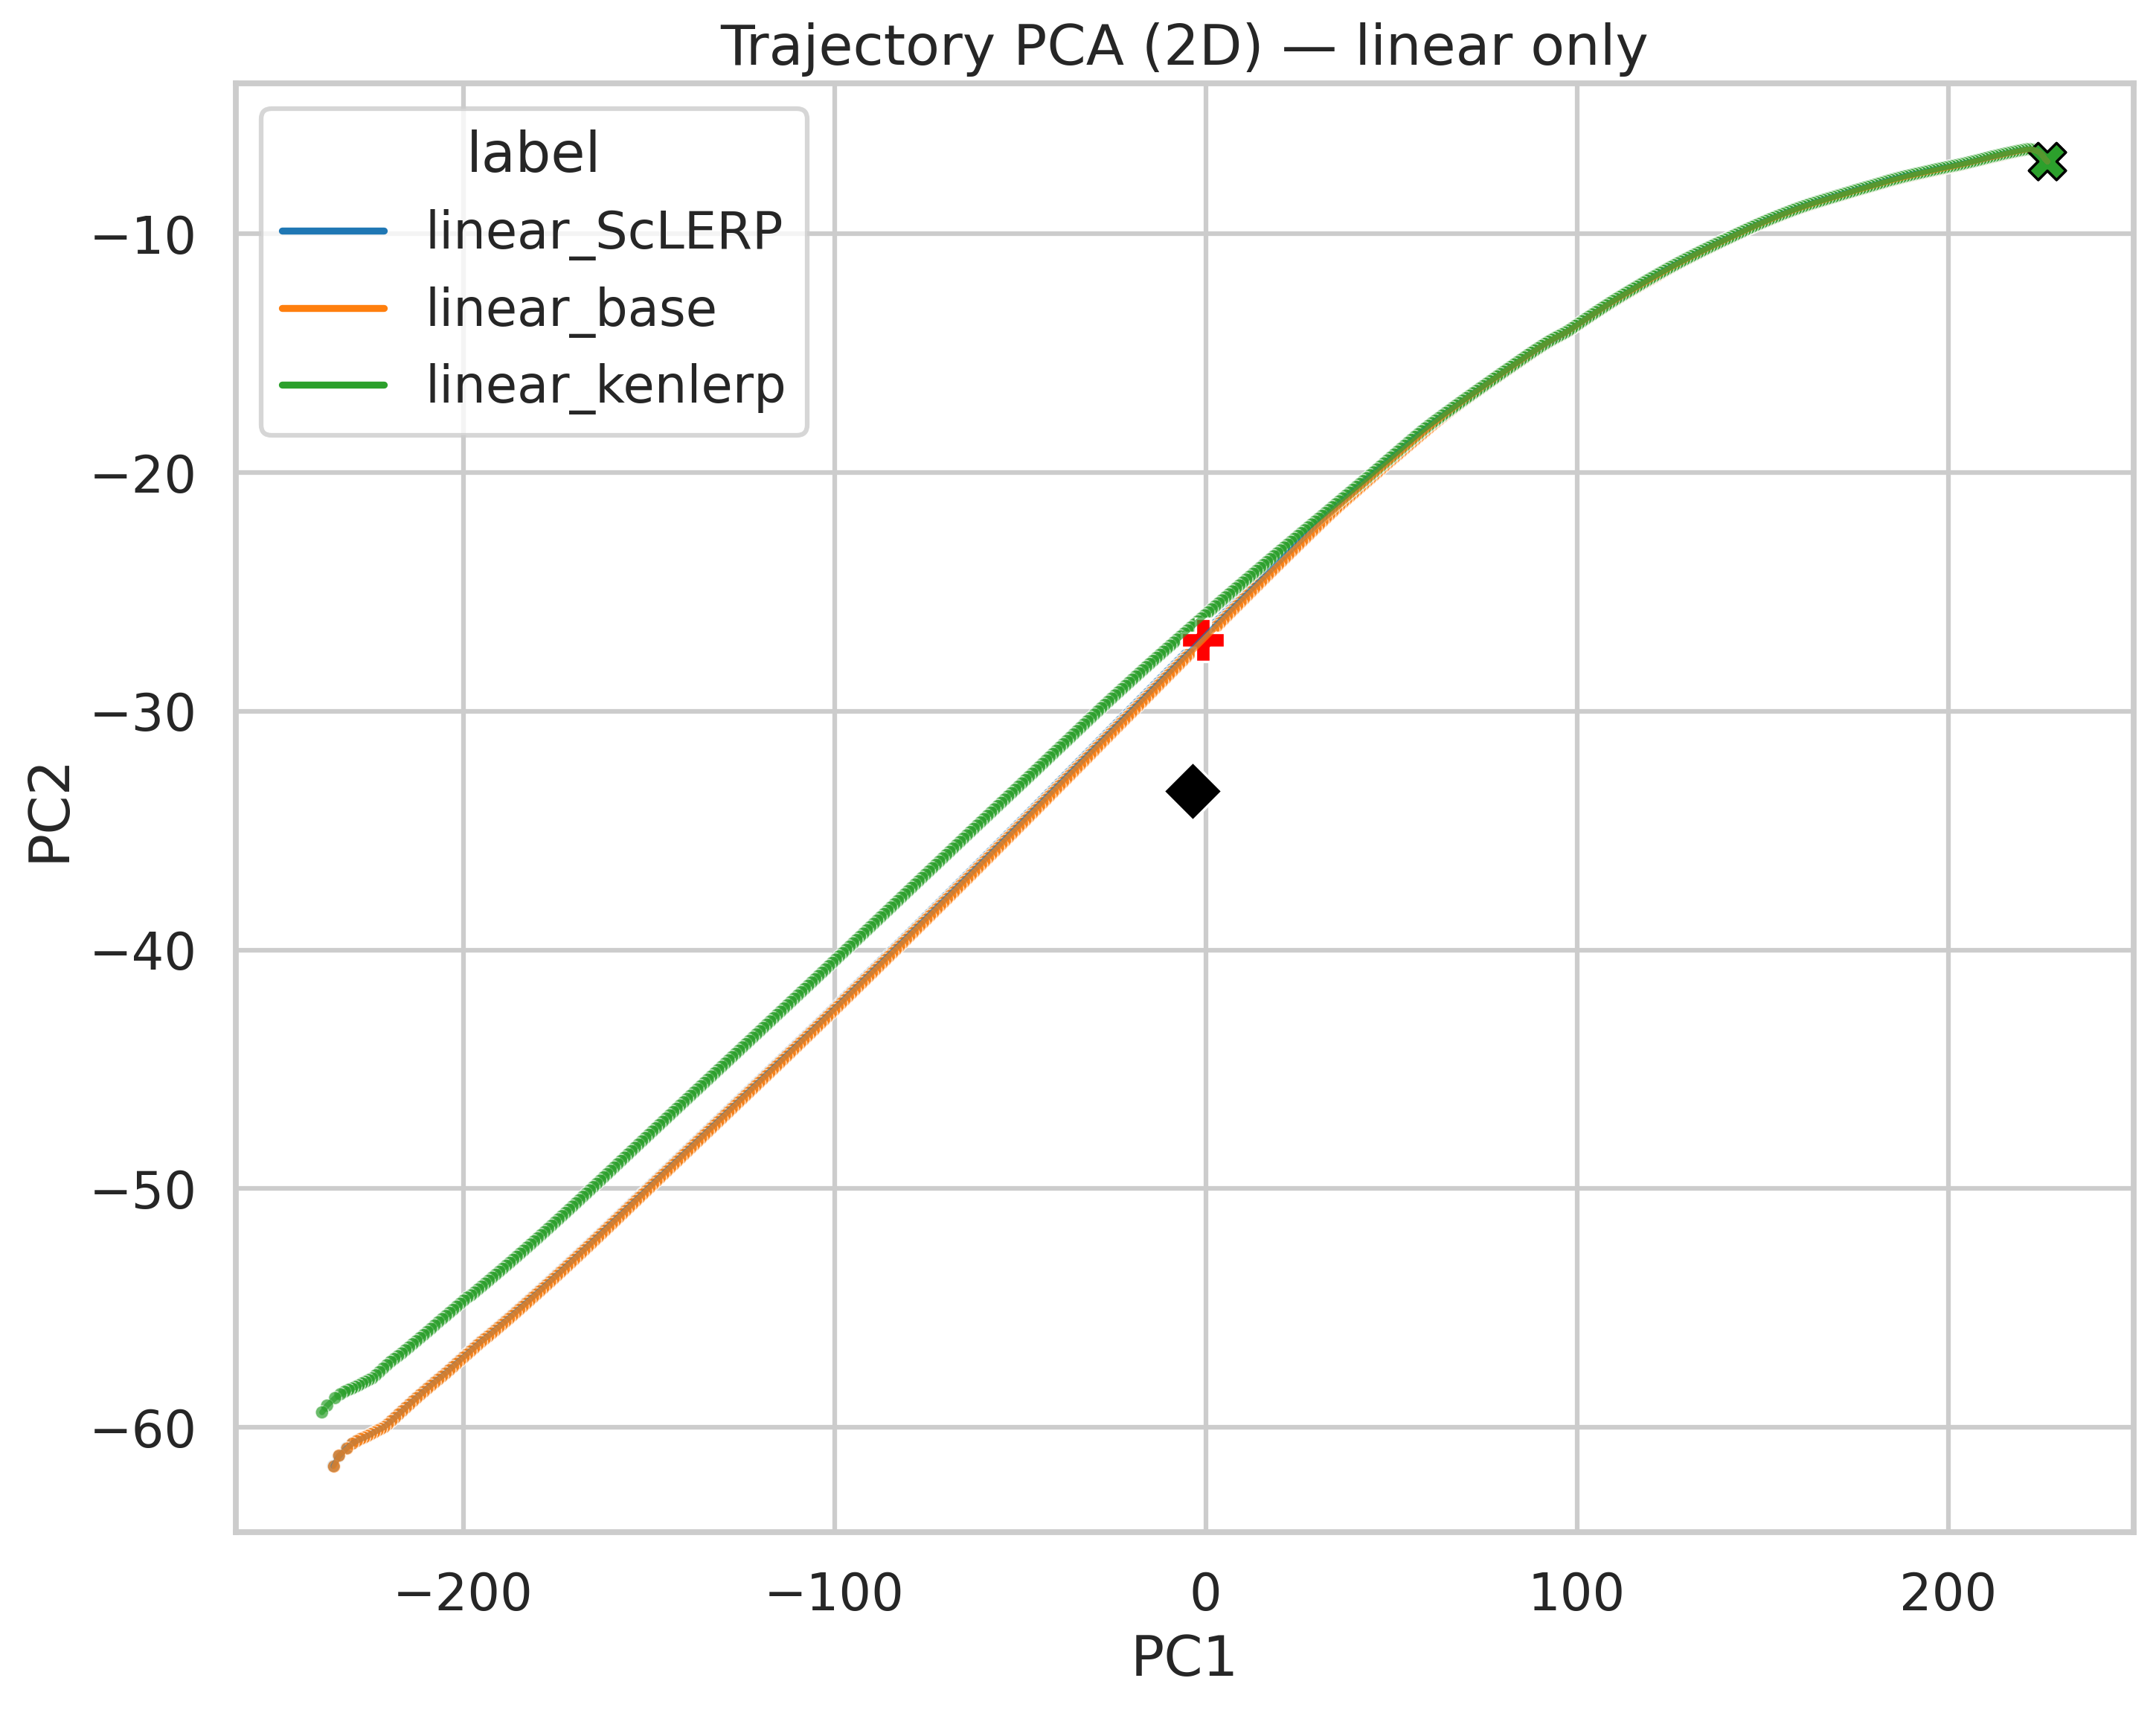

In [18]:
linear_df = traj_df[traj_df["label"].str.contains("linear", case=False, na=False)].copy()
linear_labels = sorted(linear_df["label"].unique().tolist())
linear_palette = dict(zip(linear_labels, sns.color_palette("tab10", len(linear_labels))))
linear_start = linear_df[linear_df["step"] == 0].copy()

plt.figure(figsize=(10, 8),dpi=300)
sns.lineplot(
    data=linear_df,
    x="PC1",
    y="PC2",
    hue="label",
    estimator=None,
    linewidth=1.8,
    alpha=0.7,
    palette=linear_palette,
)
sns.scatterplot(
    data=linear_df,
    x="PC1",
    y="PC2",
    hue="label",
    s=18,
    alpha=0.7,
    palette=linear_palette,
    legend=False,
)
sns.scatterplot(
    data=linear_start,
    x="PC1",
    y="PC2",
    hue="label",
    s=140,
    marker="X",
    edgecolor="black",
    linewidth=0.8,
    palette=linear_palette,
    legend=False,
)
plt.scatter(
    dq_point["PC1"],
    dq_point["PC2"],
    s=180,
    marker="D",
    color="black",
    edgecolor="white",
    linewidth=0.8,
)
plt.scatter(
    model_point["PC1"],
    model_point["PC2"],
    s=200,
    marker="P",
    color="red",
    edgecolor="white",
    linewidth=0.8,
)

plt.title("Trajectory PCA (2D) — linear only")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()
